# **Bachelor Thesis Model Kernel**

**Author:** Marek Šugár

Faculty of Mathematics, Physics and Informatics Comenius University in Bratislava

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TestDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error, accuracy_score
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TestDataFrame()

   Indicator_VIX       Date   Open_VIX   High_VIX    Low_VIX  Close_VIX  \
0            VIX 2025-09-18  14.930000  15.800000  14.330000  15.700000   
1            VIX 2025-09-19  15.760000  16.129999  15.290000  15.450000   
2            VIX 2025-09-22  16.139999  16.350000  15.780000  16.100000   
3            VIX 2025-09-23  16.100000  17.070000  15.950000  16.639999   
4            VIX 2025-09-24  16.570000  17.209999  16.180000  16.180000   
..           ...        ...        ...        ...        ...        ...   
79           VIX 2026-01-12  16.059999  16.660000  15.030000  15.120000   
80           VIX 2026-01-13  15.360000  16.500000  14.750000  15.980000   
81           VIX 2026-01-14  16.330000  18.100000  16.219999  16.750000   
82           VIX 2026-01-15  16.520000  16.540001  15.300000  15.840000   
83           VIX 2026-01-16  15.440000  16.290001  15.300000  15.860000   

    Volume_VIX  Open_1_VIX  High_1_VIX  Low_1_VIX  ...  Open_8_VIX  \
0          0.0   16.420000   

# **k-Nearest Neighbours (KNN) Algorithm**

Even though **k-Nearest Neighbours (KNN)** ML algorithm is considered to be rather simple, straightforward, easily interpretable and for such complex and highly volatile stock price data could be viewed as a model architecture with smaller use perspective there are a few research papers dealing with implementing such algorithm for predicting financial, thus stock data.

Nanda and his team used this technique solely in order to predict the next month EOM closing price of **Gold** (Nanda et al., 2024). Even though they had not used eny exogenous data as feature, they had done their prediction as a univariate time series, they were able to achieve a intriguing **MAPE** of $\approx 4.5 \%$. Even though this paper uses monthly frequency and principially different nature of data, yet still financial, we conclude high usability of such algorithm.

On the other hand, Afrasiabi et al. were able to implement such algorithm architecture to slightly different, yet familiar datasets dealing with predicting electricity price (Afrasiabi et al., 2019). In this paper, authors were able to predict next-day's electricity price with **MAPE** of $\approx 20.2 \%$. This paper shows us that there exist use cases in which the KNN performance is unsatisfactory.

Regarding primary use on stock prices data there are various papers dealing with such a problem. These data tend to be more "rich" in terms of larger amounts of data, which comes mostly from **daily** time frequency. There are many papers dealing with a very small subset of stocks from a specific market (mostly US market). Sakina and Khan in their paper, among larger number of more sophisticated methods, used KNN to predict next-day's prices of number of stock indices in various geographical locations. Surprisingly, KNN was superior to all the other listed architectures (e.g. SVM, RNN, LSTM) and in the monitored time interval, average MAPE $\approx 1.53 \%$ among all indices was achieved.

What is more, there are number of other studies implementing regression KNN on lists of several stocks in various locations (Huang, 2024), (Yin et al., 2025). Apart from that, classification approach using KNN has been studied as well (Patil et al., 2023).

Our focus shifts on segment stocks. There is a paper dealing with predicting next day's closing price of particular segment of S&P 500 index – **Information technology**. Building up on this paper, we have decided to implement KNN (and others in the future) algorithm on single stocks belonging to one particular segment of S&P 500, thus to biggest stocks in segment in the USA. Taking into account approaches used in previous papers we used both **regression** and **classification** approaches.

**REGRESSION APPROACH**

In [13]:
performance_tracker = {}

performance_mean = {}


for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 5 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    MAPEs = []
    AccuracyMean = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = KNeighborsRegressor(n_neighbors=1)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        # If our prediction is more accurate than taking the last value
        which_better = mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]) >= mean_absolute_percentage_error(Test_Target, prediction)
        AccuracyMean.append(which_better)

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction), "%", 100*mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]))
        
    performance_mean[ticker] = AccuracyMean.copy()
    performance_tracker[ticker] = MAPEs.copy()

ACN 2.803579437954808 % 2.803579437954808
ACN 2.6823465829877753 % 2.6823465829877753
ACN 3.2510116515371967 % 3.2510116515371967
ACN 0.16220352254025047 % 0.16220352254025047
ACN 1.1858353411977463 % 1.1858353411977463
ACN 0.25783319696552803 % 0.25783319696552803
ACN 0.3994826989520374 % 0.3994826989520374
ACN 1.1484026537270593 % 1.1484026537270593
ACN 1.218006452506707 % 1.218006452506707
ACN 0.691754300559306 % 0.691754300559306
ACN 0.37295765213701454 % 0.37295765213701454
ACN 4.606952242156613 % 4.606952242156613
ACN 1.0757083032722572 % 1.0757083032722572
ACN 0.262080015416251 % 0.262080015416251
ACN 1.8730925320671041 % 1.8730925320671041
ACN 2.4314171171373826 % 2.4314171171373826
ACN 1.833128540784441 % 1.833128540784441
ACN 1.5649489638917737 % 1.5649489638917737
ACN 3.325217362067116 % 3.325217362067116
ACN 0.5498896686777556 % 0.5498896686777556
ACN 0.26820310455675905 % 0.26820310455675905
ACN 0.872200167714213 % 0.872200167714213
ACN 1.2441720791242161 % 1.2441720791242

In [14]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [15]:
np.mean(list(mean_performances.values()))

np.float64(1.728903582513426)

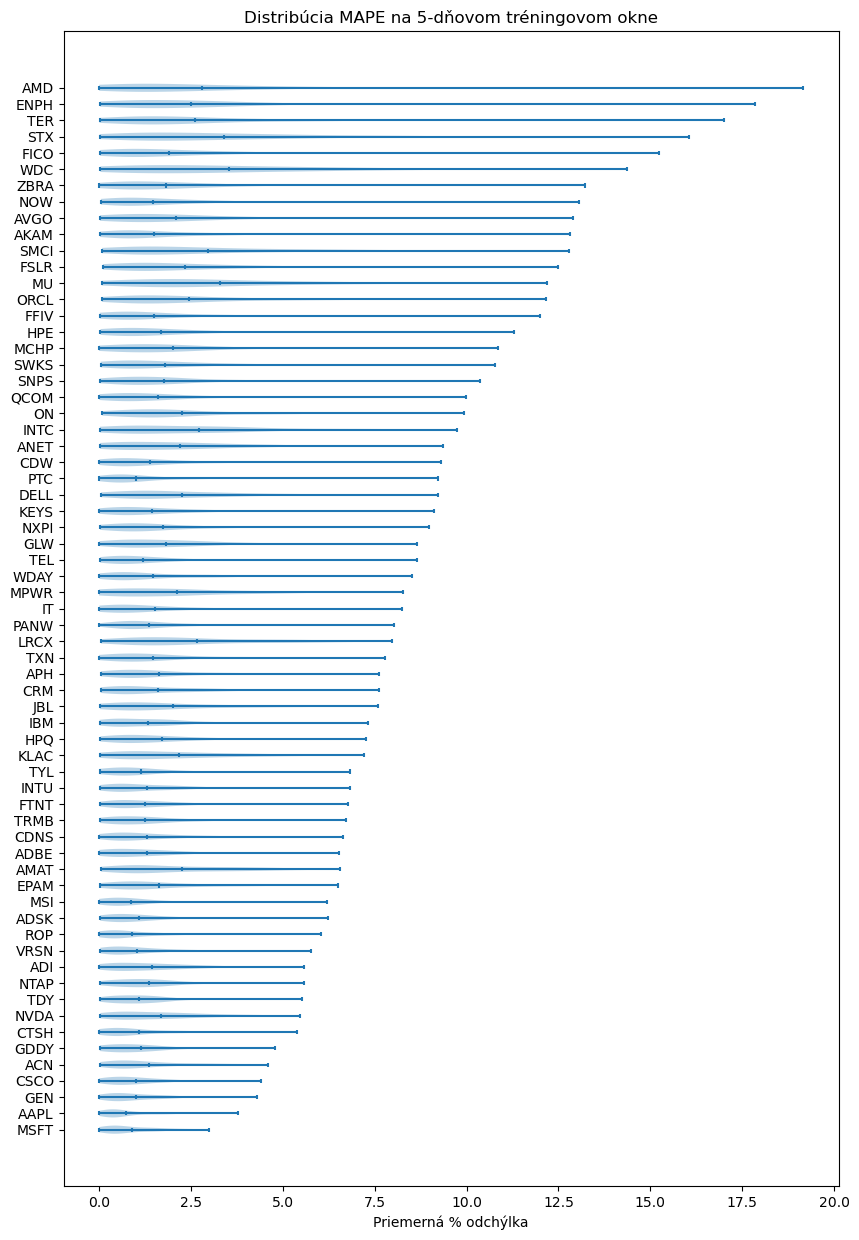

In [16]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

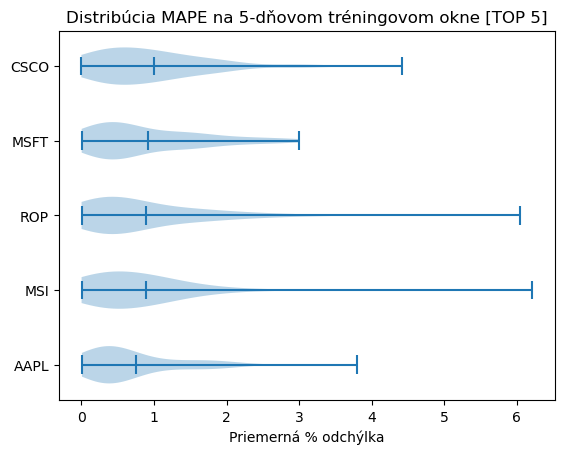

In [17]:

plt.violinplot(performance_tracker[list(mean_performances.keys())[:5]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(mean_performances.keys())[:5])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [TOP 5]")

plt.show()

In [18]:
# Pre porovnanie TOP/WORST 5
for ticker in ["VRSN", "CSCO", "IBM", "MSI", "ROP"][::-1]:
    print(ticker, np.mean(performance_tracker[ticker]))

ROP 0.8881443514756694
MSI 0.8835013197530504
IBM 1.3344146822015663
CSCO 1.007276801741744
VRSN 1.027472859306479


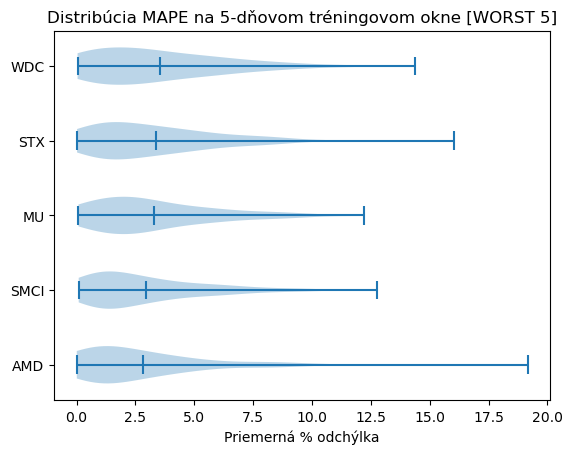

In [19]:
plt.violinplot(performance_tracker[list(mean_performances.keys())[-5:]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(mean_performances.keys())[-5:])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [WORST 5]")

plt.show()

In [20]:
# Pre porovnanie TOP/WORST 5
for ticker in ["ENPH", "SMCI", "AMD", "NVDA", "ON"][::-1]:
    print(ticker, np.mean(performance_tracker[ticker]))

ON 2.258222326058044
NVDA 1.6973128722372866
AMD 2.804362927222593
SMCI 2.9545314030076244
ENPH 2.5142087129194852


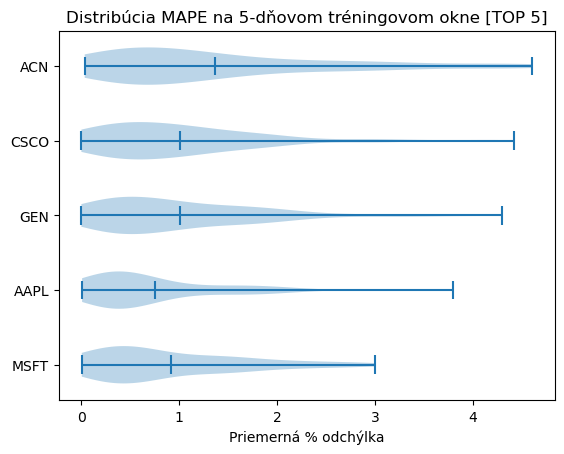

In [21]:
plt.violinplot(performance_tracker[list(range_performances.keys())[:5]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(range_performances.keys())[:5])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [TOP 5]")

plt.show()

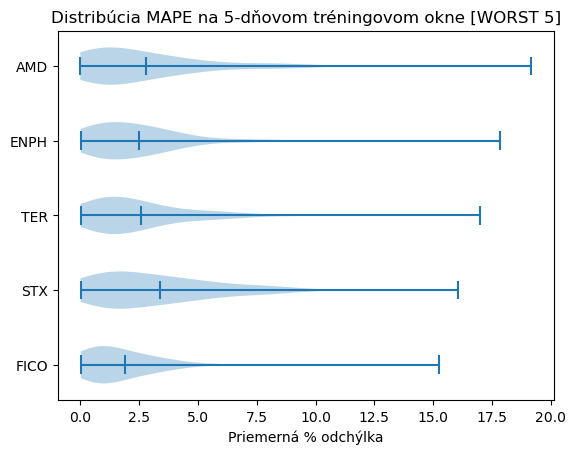

In [22]:
plt.violinplot(performance_tracker[list(range_performances.keys())[-5:]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(range_performances.keys())[-5:])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [WORST 5]")

plt.show()